# Data preparation des données de BDIFF

In [57]:
import sys
from pathlib import Path

import chardet
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# adds parent file of the current directory
# to the paths in which Python looks for modules to import
# in the current Python process
sys.path.append(str(Path.cwd().parent))

from src.config import BDIFF_RAW_DIR, BDIFF_CLEAN_DIR
from utils.cleaning_utils import delete, normalize_columns_names, normalize_text_columns_cells, optimize_numeric_column, fill_rate
from utils.analysis_utils import plot_missing_bar, plot_numeric_histograms, plot_corr_heatmap, plot_qualitative


### Création des constantes
- ALL_DATA_FILES : toutes les données
- POST_2005_DATA_FILES : données à partir de 2006 (modélisation définies en 2006)

In [58]:
# List all CSV files in DATA_RAW
ALL_DATA_FILES = list(iter(BDIFF_RAW_DIR .glob('*.csv')))

# List all recent CSV files in DATA_RAW, post 2006, without 2003 file
POST_2005_DATA_FILES = list(iter(BDIFF_RAW_DIR .glob('Incendies20*.csv')))
POST_2005_DATA_FILES = [f for f in POST_2005_DATA_FILES if "2003" and "2001" not in str(f)]

In [59]:
for file in POST_2005_DATA_FILES:
    print(f"File: {file.name}")

File: Incendies2011.csv
File: Incendies2006.csv
File: Incendies2016.csv
File: Incendies2021.csv


### Vérification de l'encodage
utf-8 à 81 % de confiance

In [60]:
# Check the encoding of the CSV files
for file in POST_2005_DATA_FILES:
    # with open(Path(BDIFF_RAW_DIR  / 'Incendies2006.csv'), 'rb') as file:
    with open(file, 'rb') as f:
        encodage = chardet.detect(f.read(10000))

    print(encodage)

{'encoding': 'utf-8', 'confidence': 0.8145920000000001, 'language': 'fr', 'mime_type': 'text/plain'}
{'encoding': 'utf-8', 'confidence': 0.810944, 'language': 'fr', 'mime_type': 'text/plain'}
{'encoding': 'utf-8', 'confidence': 0.8141360000000001, 'language': 'fr', 'mime_type': 'text/plain'}
{'encoding': 'utf-8', 'confidence': 0.816644, 'language': 'fr', 'mime_type': 'text/plain'}


In [61]:
pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

### Création d'un dictionnaire avec les Données à partir de 2006
suppression des lignes d'introduction superflues

In [62]:
def get_skiprows(file):
    '''Delete the first rows of the file until the header row is found
       The header row is identified by the presence of the string "Année" at the beginning of the line'''
    with open(file, encoding="utf-8") as f:
        for i, line in enumerate(f):
            if line.startswith("Année"):
                return i
    return 0

# returns a dict of dataframes from the CSV files
# uses the year as the key
# delete the first rows of the file until the header row is found
incendies_dict = {
    int(file.stem.replace("Incendies", "")): pd.read_csv(
        file,
        encoding=encodage["encoding"],
        sep=";",
        # Force pandas to use the new nullable dtypes for numeric columns, which can handle missing values more efficiently
        dtype_backend='numpy_nullable',
        skiprows=get_skiprows(file),
        # gere les date colonne 4
        parse_dates=[5]
    )
    for file in POST_2005_DATA_FILES
}

In [63]:
len(incendies_dict)
incendies_dict.keys()

dict_keys([2011, 2006, 2016, 2021])

In [64]:
# Concatene les dataframes en un seul dataframe
df = pd.concat(incendies_dict.values(), ignore_index=True)

In [65]:
df.shape

(52806, 24)

## Normalisation
- nom de variables en snake_case
- normalisation des cellules texte (sans accent)

In [66]:
df = normalize_columns_names(df)
df = normalize_text_columns_cells(df)



Nouveaux noms de colonnes : ['annee', 'numero', 'departement', 'code_insee', 'nom_de_la_commune', 'date_de_premiere_alerte', 'surface_parcourue_m2', 'surface_foret_m2', 'surface_maquis_garrigues_m2', 'autres_surfaces_naturelles_hors_foret_m2', 'surfaces_agricoles_m2', 'autres_surfaces_m2', 'surface_autres_terres_boisees_m2', 'surfaces_non_boisees_naturelles_m2', 'surfaces_non_boisees_artificialisees_m2', 'surfaces_non_boisees_m2', 'precision_des_surfaces', 'type_de_peuplement', 'nature', 'deces_ou_batiments_touches', 'nombre_de_deces', 'nombre_de_batiments_totalement_detruits', 'nombre_de_batiments_partiellement_detruits', 'precision_de_la_donnee']
Normalisation des colonnes de texte : ['departement', 'code_insee', 'nom_de_la_commune', 'precision_des_surfaces', 'nature', 'deces_ou_batiments_touches', 'precision_de_la_donnee']


In [67]:
df.head()

,annee,numero,departement,code_insee,nom_de_la_commune,date_de_premiere_alerte,surface_parcourue_m2,surface_foret_m2,surface_maquis_garrigues_m2,autres_surfaces_naturelles_hors_foret_m2,surfaces_agricoles_m2,autres_surfaces_m2,surface_autres_terres_boisees_m2,surfaces_non_boisees_naturelles_m2,surfaces_non_boisees_artificialisees_m2,surfaces_non_boisees_m2,precision_des_surfaces,type_de_peuplement,nature,deces_ou_batiments_touches,nombre_de_deces,nombre_de_batiments_totalement_detruits,nombre_de_batiments_partiellement_detruits,precision_de_la_donnee
0,2011,7064,2a,2a198,ota,2011-01-01 00:33:00,50,24,24,0,<NA>,<NA>,<NA>,<NA>,<NA>,2,NaN,1,involontaire (particulier),NaN,<NA>,<NA>,<NA>,NaN
1,2011,7931,11,11203,lezignan-corbieres,2011-01-02 09:10:00,1,1,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,NaN,4,NaN,NaN,<NA>,<NA>,<NA>,NaN
2,2011,4479,974,97415,saint-paul,2011-01-03 12:00:00,40000,40000,<NA>,0,<NA>,<NA>,0,0,0,0,estimees,<NA>,NaN,NaN,<NA>,<NA>,<NA>,NaN
3,2011,7942,11,11203,lezignan-corbieres,2011-01-06 11:01:00,1,1,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,NaN,4,NaN,NaN,<NA>,<NA>,<NA>,NaN
4,2011,4297,40,40113,goos,2011-01-08 08:48:00,2000,2000,<NA>,0,<NA>,<NA>,0,<NA>,<NA>,0,NaN,<NA>,involontaire (particulier),NaN,<NA>,<NA>,<NA>,NaN


In [68]:
df.describe()

,annee,numero,date_de_premiere_alerte,surface_parcourue_m2,surface_foret_m2,surface_maquis_garrigues_m2,autres_surfaces_naturelles_hors_foret_m2,surfaces_agricoles_m2,autres_surfaces_m2,surface_autres_terres_boisees_m2,surfaces_non_boisees_naturelles_m2,surfaces_non_boisees_artificialisees_m2,surfaces_non_boisees_m2,type_de_peuplement,nombre_de_deces,nombre_de_batiments_totalement_detruits,nombre_de_batiments_partiellement_detruits
count,52806.0,52806.0,52806,52806.0,48156.0,28073.0,34531.0,6588.0,6572.0,17028.0,10695.0,10428.0,35618.0,20983.0,1204.0,1205.0,1203.0
mean,2015.523899,7794.866019,2016-01-08 02:06:33.810703,46670.725997,29111.513332,24539.997293,4446.330775,3433.629781,714.746348,7844.941802,5671.528845,2667.2944,5413.966618,2.021684,0.004153,0.214938,0.128013
min,2006.0,1.0,2006-01-01 12:50:00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
25%,2010.0,3264.25,2010-10-25 08:27:45,150.0,2.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
50%,2016.0,7092.5,2016-07-14 17:10:30,1000.0,200.0,300.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
75%,2021.0,10985.0,2021-03-05 11:40:15,10000.0,3000.0,3840.0,0.0,0.0,0.0,500.0,0.0,0.0,15.0,3.0,0.0,0.0,0.0
max,2025.0,29813.0,2025-12-31 16:22:00,125520000.0,125520000.0,51160000.0,4916000.0,4050000.0,2064500.0,4916000.0,8187317.0,2200000.0,11320000.0,6.0,1.0,80.0,74.0
std,5.759668,5774.540433,NaN,1005201.945789,873384.332595,422321.690328,62156.622855,57812.870761,28074.887974,80849.084942,117406.174174,39962.180524,103329.493875,1.458692,0.064335,3.668956,2.330491


In [69]:
df.columns

Index(['annee', 'numero', 'departement', 'code_insee', 'nom_de_la_commune',
       'date_de_premiere_alerte', 'surface_parcourue_m2', 'surface_foret_m2',
       'surface_maquis_garrigues_m2',
       'autres_surfaces_naturelles_hors_foret_m2', 'surfaces_agricoles_m2',
       'autres_surfaces_m2', 'surface_autres_terres_boisees_m2',
       'surfaces_non_boisees_naturelles_m2',
       'surfaces_non_boisees_artificialisees_m2', 'surfaces_non_boisees_m2',
       'precision_des_surfaces', 'type_de_peuplement', 'nature',
       'deces_ou_batiments_touches', 'nombre_de_deces',
       'nombre_de_batiments_totalement_detruits',
       'nombre_de_batiments_partiellement_detruits', 'precision_de_la_donnee'],
      dtype='str')

### Peut-on remplacer les informations de surfaces manquantes par `0` ?

Il faut utiliser `Précision des surfaces` pour vérifier que l'ensemble des types de surface correspond à la surface totale.

In [70]:
surface_cols_principales = [
    "surface_foret_m2",
    "surface_maquis_garrigues_m2",
    "autres_surfaces_naturelles_hors_foret_m2",
    "surfaces_agricoles_m2",
    "autres_surfaces_m2",
]

comparison_5 = pd.DataFrame({
    "surface_parcourue": df["surface_parcourue_m2"],
    "surface_sum": df[surface_cols_principales].sum(axis=1),
    "nb_valeurs_renseignees": (
        df[surface_cols_principales].notna().sum(axis=1)
    ),
})

comparison_5["ecart"] = (
    comparison_5["surface_parcourue"]
    - comparison_5["surface_sum"]
)

# Vérification lorsque 4 ou 5 catégories sont renseignées
verification = comparison_5[
    comparison_5["nb_valeurs_renseignees"] >= 4
]

print(
    f"{len(verification):,} lignes avec au moins 4 catégories renseignées"
)

print(
    f"{(verification['ecart'] == 0).mean():.2%} "
    "de ces lignes ont une somme exacte."
)

6,485 lignes avec au moins 4 catégories renseignées
100.00% de ces lignes ont une somme exacte.


Pour les 6 485 lignes où au moins 4 des 5 catégories sont renseignées, la somme des catégories correspond exactement à Surface parcourue

### Il faut conserver les `NaN` comme tels

Les valeurs manquantes portent une information : la répartition de la surface parcourue entre les différentes catégories n'est pas connue.

- **`Surface parcourue (m2)`** → donnée toujours renseignée
- **Les 5 catégories de surface** → décomposition partiellement renseignée
- **`Précision des surfaces`** → indique la qualité/précision de la mesure lorsqu'elle est disponible

Les 5 colonnes :

- `Surface forêt (m2)`
- `Surface maquis garrigues (m2)`
- `Autres surfaces naturelles hors forêt (m2)`
- `Surfaces agricoles (m2)`
- `Autres surfaces (m2)`

sont bien des composantes de `Surface parcourue (m2)`.

Cependant, leurs `NaN` ne doivent pas être assimilés automatiquement à `0`.

## Sélection et Supression des variables inutiles
list `to_drop` et `dropped_cols` :
- 'numero'
- 'annee'
- 'nom_de_la_commune'
- 'deces_ou_batiments_touches'
- 'nombre_de_deces'
- 'nombre_de_batiments_totalement_detruits'
- 'nombre_de_batiments_partiellement_detruits'
- 'precision_des_surfaces'
- 'precision_de_la_donnee'

In [71]:
# list of columns to drop
to_drop = [
    'numero',
    'annee',
    'nom_de_la_commune',
    'deces_ou_batiments_touches',
    'nombre_de_deces',
    'nombre_de_batiments_totalement_detruits',
    'nombre_de_batiments_partiellement_detruits',
    'precision_des_surfaces',
    'precision_de_la_donnee'
]

dropped_cols = []


In [72]:
# df['numero'].value_counts()
# df['annee'].value_counts()
# df['nom_de_la_commune'].value_counts()
# df['deces_ou_batiments_touches'].value_counts()
# df['nombre_de_deces'].value_counts()
# df['nombre_de_batiments_totalement_detruits'].value_counts()
# df['nombre_de_batiments_partiellement_detruits'].value_counts()
# df['precision_des_surfaces'].value_counts()
# df['precision_de_la_donnee'].value_counts()

In [73]:
# Delete the unwanted columns

# Attention : la fonction retourne un nouveau DataFrame, il faut le réaffecter.
for col in to_drop:
    df = delete(df, col, dropped_cols)


In [74]:
df.shape

(52806, 15)

In [75]:
df.columns

Index(['departement', 'code_insee', 'date_de_premiere_alerte',
       'surface_parcourue_m2', 'surface_foret_m2',
       'surface_maquis_garrigues_m2',
       'autres_surfaces_naturelles_hors_foret_m2', 'surfaces_agricoles_m2',
       'autres_surfaces_m2', 'surface_autres_terres_boisees_m2',
       'surfaces_non_boisees_naturelles_m2',
       'surfaces_non_boisees_artificialisees_m2', 'surfaces_non_boisees_m2',
       'type_de_peuplement', 'nature'],
      dtype='str')

### Recherche de variable vide ou à une seule modalité
Il n'y en a pas

In [76]:
# Détection des variables qui n'ont qu'une seule modalité
# NaN étant considéré comme une modalité .....  (dropna=False)
unique_value_cols = df.columns[df.nunique(dropna=False)==1].tolist()
unique_value_cols

[]

In [77]:
# Détection des variables vide
empty = df.columns[df.isna().all()].tolist()
empty

[]

## Typage - economie


In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52806 entries, 0 to 52805
Data columns (total 15 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   departement                               52806 non-null  str           
 1   code_insee                                52806 non-null  str           
 2   date_de_premiere_alerte                   52806 non-null  datetime64[us]
 3   surface_parcourue_m2                      52806 non-null  Int64         
 4   surface_foret_m2                          48156 non-null  Int64         
 5   surface_maquis_garrigues_m2               28073 non-null  Int64         
 6   autres_surfaces_naturelles_hors_foret_m2  34531 non-null  Int64         
 7   surfaces_agricoles_m2                     6588 non-null   Int64         
 8   autres_surfaces_m2                        6572 non-null   Int64         
 9   surface_autres_terres_boisees_m2       

In [79]:
colonnes_numeriques = df.select_dtypes(include=['number']).columns

for col in colonnes_numeriques:
    print(f"Lancement de l'optimisation pour : {col}")
    df = optimize_numeric_column(df, col)


Lancement de l'optimisation pour : surface_parcourue_m2
Lancement de l'optimisation pour : surface_foret_m2
Lancement de l'optimisation pour : surface_maquis_garrigues_m2
Lancement de l'optimisation pour : autres_surfaces_naturelles_hors_foret_m2
Lancement de l'optimisation pour : surfaces_agricoles_m2
Lancement de l'optimisation pour : autres_surfaces_m2
Lancement de l'optimisation pour : surface_autres_terres_boisees_m2
Lancement de l'optimisation pour : surfaces_non_boisees_naturelles_m2
Lancement de l'optimisation pour : surfaces_non_boisees_artificialisees_m2
Lancement de l'optimisation pour : surfaces_non_boisees_m2
Lancement de l'optimisation pour : type_de_peuplement


In [80]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52806 entries, 0 to 52805
Data columns (total 15 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   departement                               52806 non-null  str           
 1   code_insee                                52806 non-null  str           
 2   date_de_premiere_alerte                   52806 non-null  datetime64[us]
 3   surface_parcourue_m2                      52806 non-null  Int32         
 4   surface_foret_m2                          48156 non-null  Int32         
 5   surface_maquis_garrigues_m2               28073 non-null  Int32         
 6   autres_surfaces_naturelles_hors_foret_m2  34531 non-null  Int32         
 7   surfaces_agricoles_m2                     6588 non-null   Int32         
 8   autres_surfaces_m2                        6572 non-null   Int32         
 9   surface_autres_terres_boisees_m2       

### Métropole, Corse, Outre Mer - Filtre outre_mer
- Corse: 2A, 2B
- Outre-mer : 971 à 976

In [81]:
# Exclut les départements d'outre-mer
corse = ['2A', '2B']
outre_mer = ['971', '972', '973', '974', '976', '977', '978', '984', '986', '987', '988']

df = df[~df['departement'].isin(outre_mer)]

In [82]:
df['departement'].value_counts()


departement
2b    4993
2a    4694
13    4302
33    3555
34    3232
      ... 
80       6
78       5
51       3
62       3
94       1
Name: count, Length: 93, dtype: int64

### Type de peuplement

In [83]:
# Etude des modalité de 'type_de_peuplement'
df['type_de_peuplement'].value_counts()

type_de_peuplement
1    13006
4     3226
3     1651
5     1446
2     1399
6      255
Name: count, dtype: Int64

## Etats des données

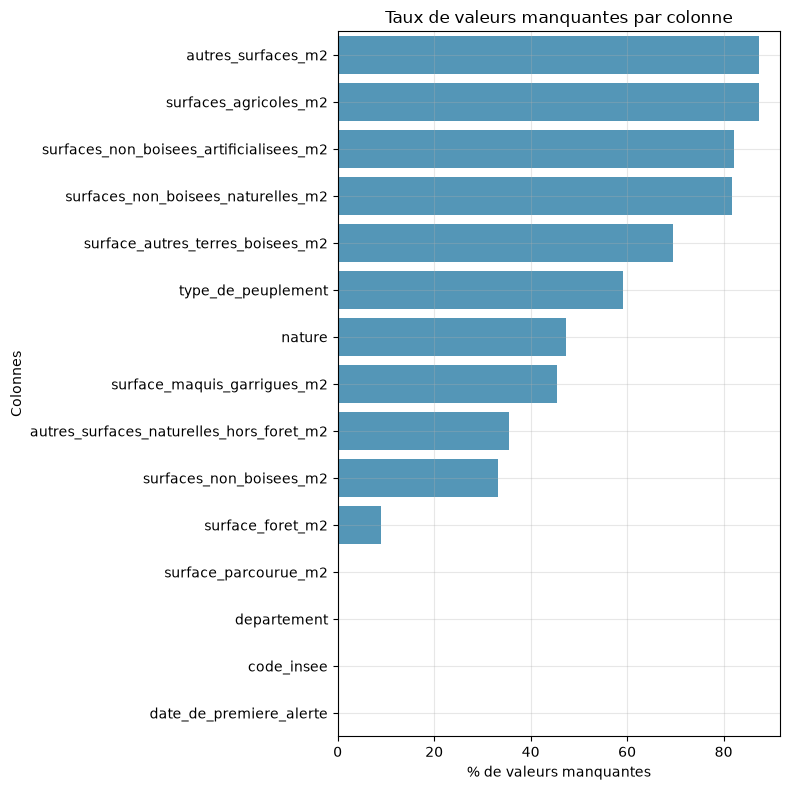

In [84]:
plot_missing_bar(df, figsize=(8,8))

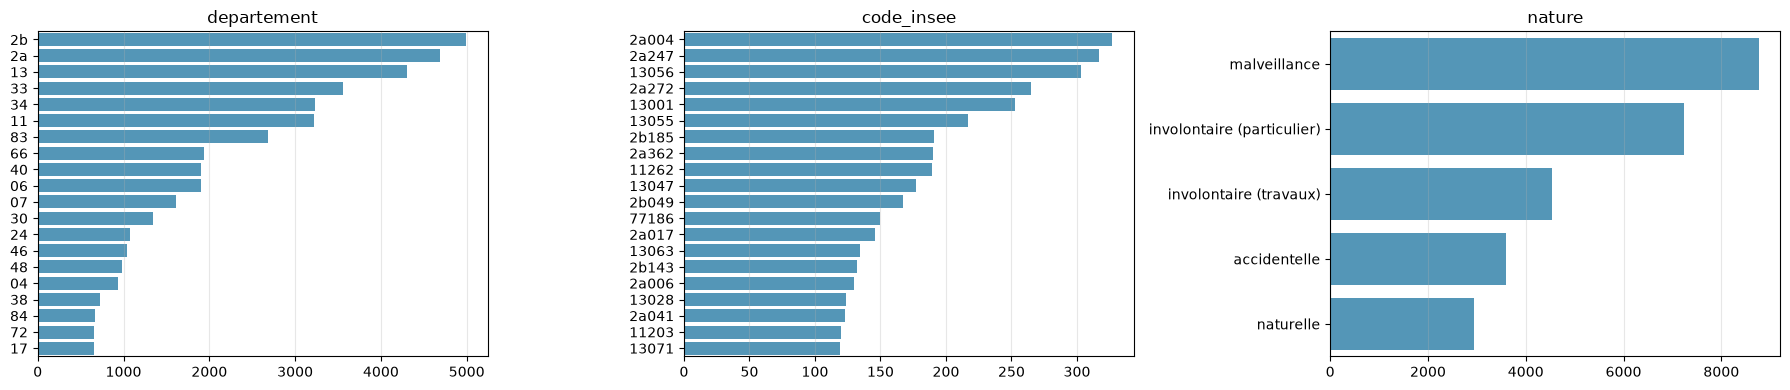

In [85]:
plot_qualitative(df, n_cols=3)

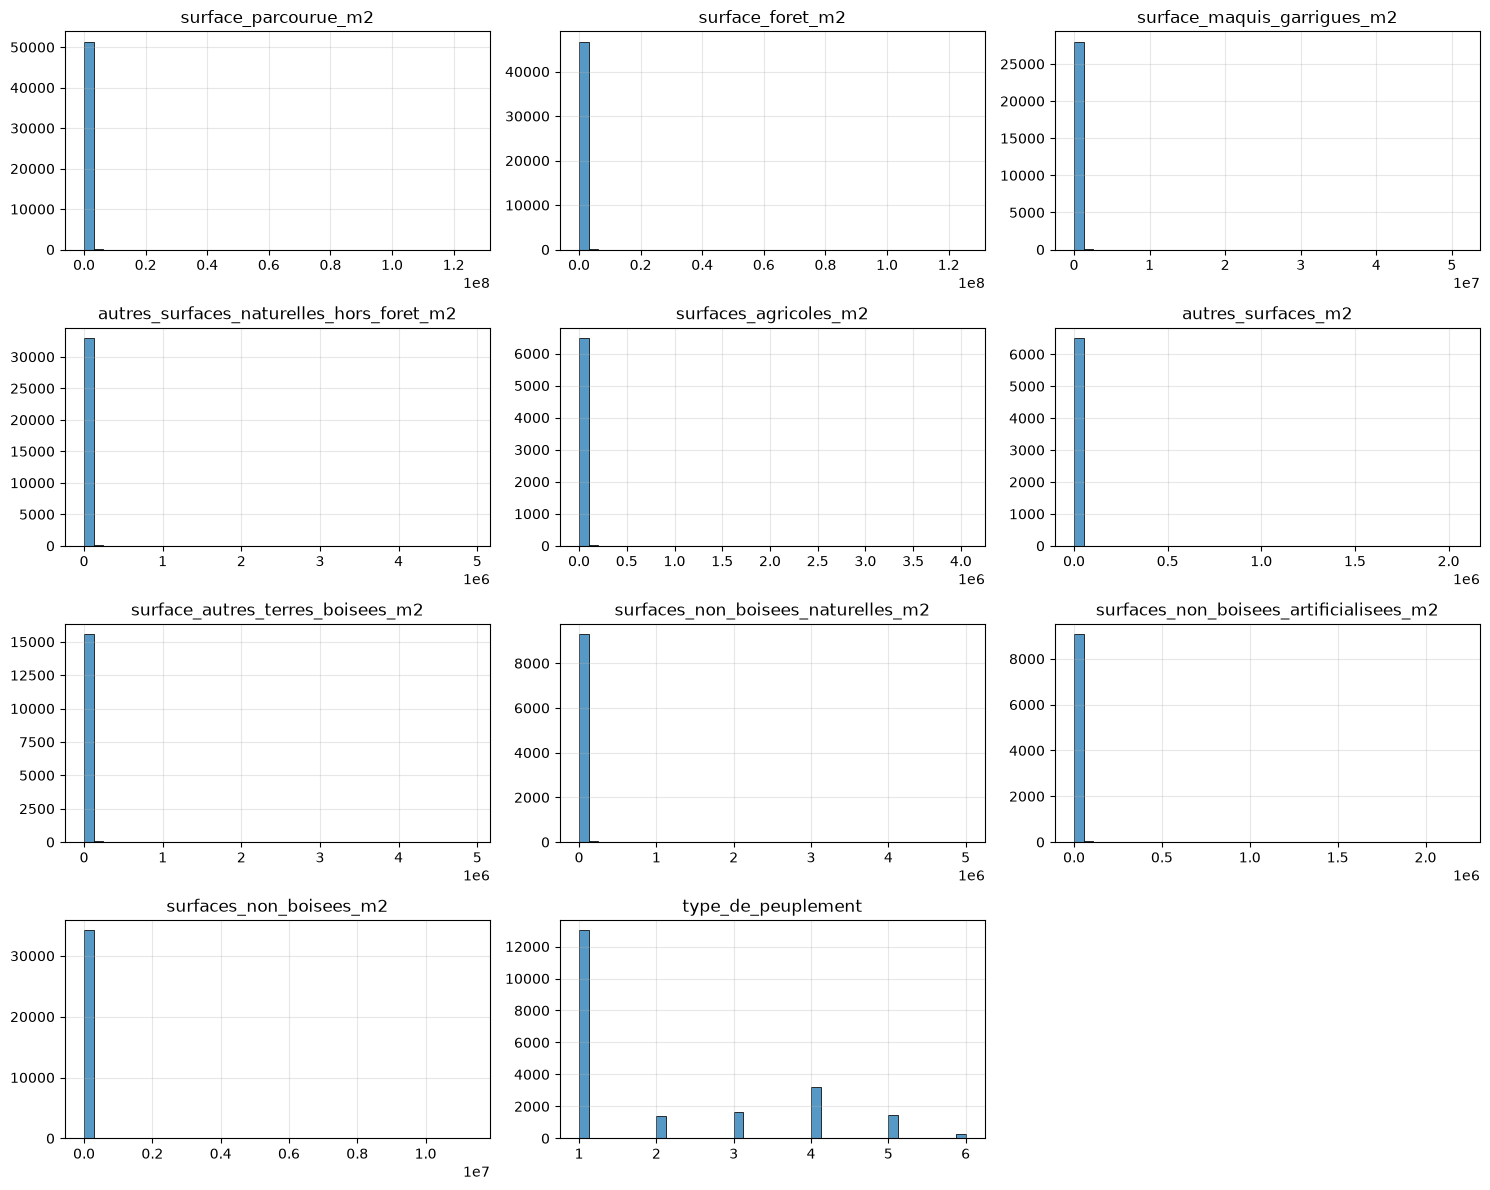

In [86]:
plot_numeric_histograms(df, bins=40, n_cols=3)


### 'peuplement' à quoi correspondent les entier de 1 à 6 ?


## Export
vers DATA_CLEAN_DIR (data/data_clean/)

In [87]:
df.to_parquet(
    BDIFF_CLEAN_DIR / "incendies_metropole_corse.parquet",
    index=False
)


Normalisation utile pour :
- Logistic Regression
- SVM
- KNN
- réseaux de neurones
- PCA

le scaling est généralement inutile pour des modèles à arbres comme :
- DecisionTree
- RandomForest
- ExtraTrees
- Gradient Boosting